In [1]:
import logging
from pyspark import SparkConf
from pyspark import SparkContext
from pyspark.sql import SparkSession
from pyspark.sql.functions import month, days
from pyspark.sql.types import StructType, StructField, LongType, DoubleType, StringType, TimestampNTZType

In [3]:
def create_spark_session(app_name: str) -> SparkSession:
    spark = (
        SparkSession.builder
        .master("spark://spark-master:7077")
        .appName(app_name)
        .config("spark.sql.extensions", "org.apache.iceberg.spark.extensions.IcebergSparkSessionExtensions")
        .config("spark.sql.catalog.lakehouse_prod","org.apache.iceberg.spark.SparkCatalog")
        .config("spark.sql.catalog.lakehouse_prod.type", "hive")
        .config("spark.sql.catalog.lakehouse_prod.uri","thrift://hive-metastore:9083")
        .config("spark.sql.catalog.lakehouse_prod.warehouse","s3a://lakehouse-prod-bucket/warehouse/")
        .config("spark.sql.catalog.lakehouse_prod.io-impl","org.apache.iceberg.aws.s3.S3FileIO")
        .config("spark.hadoop.fs.s3a.endpoint", "http://minio:9000")
        .config("spark.hadoop.fs.s3a.path.style.access", "true")
        .config("spark.hadoop.fs.s3a.impl", "org.apache.hadoop.fs.s3a.S3AFileSystem")
        .config("spark.hadoop.fs.s3a.connection.ssl.enabled", "false")
        .config("spark.sql.adaptive.enabled", "true")
        .config("spark.serializer", "org.apache.spark.serializer.KryoSerializer")
        .enableHiveSupport()
        .getOrCreate()
    )

    spark.sparkContext.setLogLevel("ERROR")
    print("NOTE: SparkSession created successfully!")

    return spark

In [4]:
app_name = 'Spark-Iceberg-Test'
spark = create_spark_session(app_name)
spark

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/03/27 18:42:11 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


NOTE: SparkSession created successfully!


In [5]:
spark._jsc.hadoopConfiguration().get("fs.s3a.access.key")

'minioadmin'

In [6]:
spark.sql("USE lakehouse_prod").show()

++
||
++
++



In [9]:
spark.sql("SHOW DATABASES IN lakehouse_prod").show()

+---------+
|namespace|
+---------+
|bronze_db|
|  default|
|  gold_db|
|silver_db|
|  test_db|
+---------+



In [7]:
spark.sql("SHOW CATALOGS").show()

+--------------+
|       catalog|
+--------------+
|lakehouse_prod|
| spark_catalog|
+--------------+



In [8]:
spark.sql("CREATE DATABASE IF NOT EXISTS lakehouse_prod.test_db").show()

++
||
++
++



In [7]:
spark.sql('''
CREATE TABLE IF NOT EXISTS lakehouse_prod.test_db.customer (
    customer_id BIGINT,
    email STRING,
    first_name STRING,
    datetime_updated TIMESTAMP
) 
USING iceberg;
''').show()

++
||
++
++



In [11]:
spark.sql('''
INSERT INTO lakehouse_prod.test_db.customer VALUES
(1, 'new_email1@test.com', 'Alice', TIMESTAMP('2024-02-01 10:00:00')),
(2, 'bob@test.com', 'Bob', TIMESTAMP('2024-01-05 12:00:00')),
(4, 'david@test.com', 'David', TIMESTAMP('2024-02-10 09:00:00'));
''').show()

++
||
++
++



In [10]:
spark.sql('''
CREATE TABLE IF NOT EXISTS lakehouse_prod.test_db.dim_customer (
    customer_id BIGINT,
    email STRING,
    first_name STRING,
    datetime_updated TIMESTAMP,
    valid_from TIMESTAMP,
    valid_to TIMESTAMP,
    is_current BOOLEAN,
    is_active BOOLEAN
) 
USING iceberg
PARTITIONED BY (is_current);

''').show()

++
||
++
++



In [12]:
spark.sql('''
INSERT INTO lakehouse_prod.test_db.dim_customer VALUES
(1, 'old_email1@test.com', 'Alice', TIMESTAMP('2024-01-01 10:00:00'),
 TIMESTAMP('2024-01-01 10:00:00'), NULL, true, true),
(2, 'bob@test.com', 'Bob', TIMESTAMP('2024-01-05 12:00:00'),
 TIMESTAMP('2024-01-05 12:00:00'), NULL, true, true),
(3, 'charlie@test.com', 'Charlie', TIMESTAMP('2024-01-07 15:00:00'),
 TIMESTAMP('2024-01-07 15:00:00'), NULL, true, true);
''').show()

++
||
++
++



In [13]:
# Dimension Table (Source)
spark.sql('SELECT * FROM lakehouse_prod.test_db.dim_customer').show()

+-----------+-------------------+----------+-------------------+-------------------+--------+----------+---------+
|customer_id|              email|first_name|   datetime_updated|         valid_from|valid_to|is_current|is_active|
+-----------+-------------------+----------+-------------------+-------------------+--------+----------+---------+
|          1|old_email1@test.com|     Alice|2024-01-01 10:00:00|2024-01-01 10:00:00|    NULL|      true|     true|
|          2|       bob@test.com|       Bob|2024-01-05 12:00:00|2024-01-05 12:00:00|    NULL|      true|     true|
|          3|   charlie@test.com|   Charlie|2024-01-07 15:00:00|2024-01-07 15:00:00|    NULL|      true|     true|
+-----------+-------------------+----------+-------------------+-------------------+--------+----------+---------+



In [14]:
# Source Table
spark.sql('SELECT * FROM lakehouse_prod.test_db.customer').show()

+-----------+-------------------+----------+-------------------+
|customer_id|              email|first_name|   datetime_updated|
+-----------+-------------------+----------+-------------------+
|          1|new_email1@test.com|     Alice|2024-02-01 10:00:00|
|          2|       bob@test.com|       Bob|2024-01-05 12:00:00|
|          4|     david@test.com|     David|2024-02-10 09:00:00|
+-----------+-------------------+----------+-------------------+



# MERGE INTO is used to UPDATE/DELETE/INSERT rows into a target table based on data in the source table
MERGE INTO is used to update, delete, or insert rows into a target table based on data in a source table.

Merge into is similar to a full outer join. Instead of the join clause, you have a target USING source on t.id=s.id, and instead of producing an output, it updates the target table.

The updates to the target table are based on 3 clauses:

WHEN MATCHED The rows from the source that match rows from the target can be used to UPDATE or DELETE target rows.
WHEN NOT MATCHED The rows from the source with no match in the target table can be INSERTED into the target table.
WHEN NOT MATCHED BY SOURCE The rows from the target that do not match in the source table can be UPDATED or DELETED.

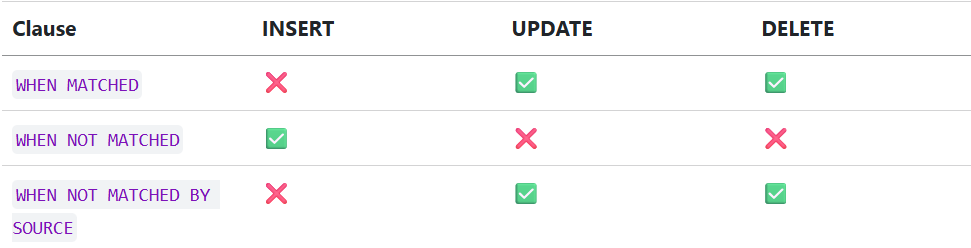

\The 3 clauses can have additional conditions. You can define multiple of the above clauses with additional conditions, which will be evaluated in the order that they are specified.

Note: In the WHEN MATCHED clause, we should ensure that each row in the source table matches only one row in the target table for UPDATE or DELETE. This restriction ensures that each target row can only be updated by a single source row, as MERGE INTO was designed primarily as a row-level update mechanism.

In [18]:
### Using SCD Type 2 with Spark SQL
spark.sql(
'''
With customers_with_updates as (
select c.*
    from lakehouse_prod.test_db.customer c
    join lakehouse_prod.test_db.dim_customer dc
    on c.customer_id = dc.customer_id -- Customer exists in dim_customer
    where c.datetime_updated > dc.datetime_updated -- ensure that the update in upstream customer is newer than the latest data in dim_customer
    and dc.is_current = true -- only look at the most current state of customer in dim_customer
)
MERGE INTO lakehouse_prod.test_db.dim_customer t -- target dim_customer to update
USING (
    select customer_id as join_key, * from lakehouse_prod.test_db.customer -- New customers to be INSERTED, existing customers to be UPDATED
    union all
    select NULL as join_key, * from customers_with_updates -- Existing customers with updated values to be INSERTED
    ) s
ON t.customer_id = s.join_key -- natural key for customer

WHEN MATCHED AND is_current = true AND s.datetime_updated > t.datetime_updated -- condition to UPDATE most recent customers in dim_customer that have had updates
    THEN UPDATE SET is_current = false, valid_to = s.datetime_updated
    
WHEN NOT MATCHED 
    THEN INSERT (customer_id,email,first_name,datetime_updated,valid_from,is_current,is_active) -- condition to INSERT new customers and customers with updates
    VALUES (s.customer_id,s.email,s.first_name,s.datetime_updated,s.datetime_updated,true,true)

WHEN NOT MATCHED BY SOURCE -- condition to set deleted customers in dim_customer to be in-active
    THEN UPDATE SET is_active = false AND valid_to = current_timestamp()
''' 
).show()

++
||
++
++



In [19]:
# Dimension Table After SCD Type 2 process
spark.sql('SELECT * FROM lakehouse_prod.test_db.dim_customer').show()

+-----------+-------------------+----------+-------------------+-------------------+-------------------+----------+---------+
|customer_id|              email|first_name|   datetime_updated|         valid_from|           valid_to|is_current|is_active|
+-----------+-------------------+----------+-------------------+-------------------+-------------------+----------+---------+
|          1|new_email1@test.com|     Alice|2024-02-01 10:00:00|2024-02-01 10:00:00|               NULL|      true|     true|
|          2|       bob@test.com|       Bob|2024-01-05 12:00:00|2024-01-05 12:00:00|               NULL|      true|     true|
|          3|   charlie@test.com|   Charlie|2024-01-07 15:00:00|2024-01-07 15:00:00|               NULL|      true|    false|
|          4|     david@test.com|     David|2024-02-10 09:00:00|2024-02-10 09:00:00|               NULL|      true|     true|
|          1|old_email1@test.com|     Alice|2024-01-01 10:00:00|2024-01-01 10:00:00|2024-02-01 10:00:00|     false|   

## 3.1. Source includes 2 versions of upstream customer data: one for insert and the other for update
As the SCD2 pipeline involves INSERTS and UPDATES, we need to define the rows to be considered for updates and inserts. In the code, we will define our source as a combination of the following:

All the data from the customer table to ensure that new rows are inserted and existing rows (in target) are updated with appropriate valid_to and that is_current is set to False.
Only the data in the source that has corresponding rows in the table -> These indicate updated data and will be inserted as new rows into the target.
We implement the above in SQL as follows:

source as is + an additional column called join_key whose value will be the natural key of this table. This includes new rows to be inserted and existing rows (in target) to be updated.

source as is + an additional column called join_key whose value will be NULL. This includes new rows to be inserted into the target.

With customers_with_updates as (
select c.*
    from prod.db.customer c
    join prod.db.dim_customer dc
    on c.customer_id = dc.customer_id -- Customer exists in dim_customer
    where c.datetime_updated > dc.datetime_updated -- ensure that the update in upstream customer is newer than the latest data in dim_customer
    and dc.is_current = true -- only look at the most current state of customer in dim_customer
)
MERGE INTO prod.db.dim_customer t -- target dim_customer to update
USING (
    select customer_id as join_key, * from prod.db.customer -- New customers to be INSERTED, existing customers to be UPDATED
    union all
    select NULL as join_key, * from customers_with_updates -- Existing customers with updated values to be INSERTED
    ) 
-- .....

There are 2 key techniques we use: 1. NULL as join_key technique to insert rows (that have IDs in the target table). 2. The c.datetime_updated > dc.datetime_updated and dc.is_current = true technique indicates rows needing updating. * The datetime comparison ensures that the upstream change is more recent than the value in dim_customer. * The is_current = true ensures that we only get one row per customer (in SCD2, there will be multiple rows per customer, but only one is_current=True per customer).

# 3.2. Updates to the target table
The target table is updated by 3 MATCHING clauses, they are:

The WHEN MATCHED AND is_current = true AND s.datetime_updated > t.datetime_updated clause is used to update existing SCD2 rows, set them as not current, and set the vaid_to date as the date that the upstream customer table was last updated.

The WHEN NOT MATCHED clause inserts “new” rows into the SCD2 table. In this context, new customers and customers with updated data are inserted into the dim_customer table.

The WHEN NOT MATCHED BY SOURCE clause is used to update rows in the Target that no longer have a corresponding row in the upstream customer table(due to customer deletion) as inactive.

-- condition to UPDATE most recent customers in dim_customer that have had updates
WHEN MATCHED AND is_current = true AND s.datetime_updated > t.datetime_updated  THEN UPDATE SET is_current = false, valid_to = s.datetime_updated

-- condition to INSERT new customers and customers with updates
WHEN NOT MATCHED THEN INSERT (customer_id,email,first_name,datetime_updated,valid_from,is_current,is_active)  VALUES (s.customer_id,s.email,s.first_name,s.datetime_updated,s.datetime_updated,true,true)

-- condition to set deleted customers in dim_customer to be in-active
WHEN NOT MATCHED BY SOURCE  THEN UPDATE SET is_active = false AND valid_to = current_timestamp()

In [20]:
spark.stop()

**Source:**

https://www.startdataengineering.com/post/create-scd2-table-with-merge-into-with-spark-iceberg/